# GMM Cluster Profile Analysis

Standalone profiling notebook for the 7-component developer-level GMM produced in `GMM_Cluster.ipynb`.

Reads directly from `dev_gmm_clusters_v1` (hard labels + posteriors) joined to `dev_profile_final_v4`
(model features + profile/demographic columns). No refitting required.

**Sections**
1. Setup and data load
2. Cluster size overview
3. Basic feature profiles — centroids across six feature groups
4. Demographic profiles — persona, lifecycle, dormancy, effort, journey stage, country, account type
5. Summary reference table

## 1. Setup and data load

In [8]:
import warnings
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

DB_PATH = 'developer_project.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)

# Verify required tables exist
existing = set(
    con.execute("SELECT table_name FROM information_schema.tables WHERE table_schema='main'").fetchdf()['table_name']
)
for t in ['dev_gmm_clusters_v1', 'dev_profile_final_v4']:
    if t not in existing:
        raise RuntimeError(f'Missing table: {t}. Run GMM_Cluster.ipynb first.')
print('Tables present:', sorted(existing))

Tables present: ['activity_base', 'activity_base_v2', 'activity_clean', 'activity_dictionary_v2', 'activity_effort_mapping_ai_v2', 'activity_enriched_v1', 'activity_final', 'activity_labeled_v2', 'activity_ontology_v1', 'activity_raw', 'activity_score_mapping_clean', 'activity_score_mapping_raw', 'activity_work', 'contact_clean', 'contact_final', 'contact_one_row_v2', 'contact_raw', 'contact_work', 'dev_activation_v1', 'dev_activation_v2', 'dev_contact_persona_v2', 'dev_dormancy_base_v1', 'dev_dormancy_holdout_validation_v1', 'dev_dormancy_status_v1', 'dev_dormancy_status_v2', 'dev_effort_level_v2', 'dev_features_0_30d_v2', 'dev_features_180d_v1', 'dev_features_30_90d_v2', 'dev_features_30d_v1', 'dev_features_90_180d_v2', 'dev_features_90d_v1', 'dev_features_lifetime_v1', 'dev_features_lifetime_v2', 'dev_gmm_clusters_v1', 'dev_gmm_weekly_clusters_v1', 'dev_journey_state_v2', 'dev_meaningful_return_intervals_v1', 'dev_meaningful_week_v1', 'dev_meaningful_week_v2', 'dev_period_30d_featur

In [9]:
# ── Feature groups (must match GMM_Cluster.ipynb) ────────────────────────────
VOLUME_BREADTH = [
    'log_clipped_lifetime_activity_count_p99',
    'log_clipped_lifetime_activity_score_sum_p99',
    'lifetime_unique_activity_types',
    'lifetime_unique_modalities',
    'lifetime_active_weeks',
]
EFFORT = [
    'log_clipped_lifetime_total_confidence_weighted_effort_p99',
    'log_clipped_lifetime_effort_x_activity_score_sum_p99',
    'lifetime_avg_effort_rank',
    'effort_per_activity_lifetime',
    'developer_effort_score',
]
MODALITY_COUNTS = [
    'lifetime_build_count', 'lifetime_champion_count', 'lifetime_evaluate_count',
    'lifetime_learn_count', 'lifetime_discover_count',
    'lifetime_dli_training_count', 'lifetime_webinar_count', 'lifetime_forum_count',
    'lifetime_bug_count', 'lifetime_hackathon_count', 'lifetime_api_count',
    'lifetime_devzone_download_count', 'lifetime_ngc_download_count',
]
RECENCY = [
    'log_activity_count_0_30d', 'log_activity_count_30_90d', 'log_activity_count_90_180d',
    'weighted_recent_activity', 'weighted_recent_build', 'weighted_recent_confidence_effort',
    'days_since_last_activity', 'activity_velocity_0_30_vs_30_90',
]
PERSONA_SHARE = [
    'cuda_share', 'genai_share', 'robotics_share', 'simulation_share',
    'learning_community_share', 'persona_entropy',
]
FLAGS = ['recent_build_flag', 'recent_champion_flag', 'mixed_persona_flag']
MODEL_FEATURES = VOLUME_BREADTH + EFFORT + MODALITY_COUNTS + RECENCY + PERSONA_SHARE + FLAGS

PROFILE_COLS = [
    'persona', 'final_lifecycle_status', 'behavior_journey_stage_30d',
    'dormancy_status', 'developer_effort_level', 'developer_effort_rank',
    'country', 'account_type',
]

# Cluster labels (5 and 6 were unlabelled in GMM_Cluster; assigned here from centroid analysis)
CLUSTER_LABELS = {
    -1: 'unactivated',
     0: 'dormant_cuda_tourists',
     1: 'high_effort_at_risk_builders',
     2: 'elite_power_users',
     3: 'low_effort_genai_tourists',
     4: 'active_genai_api_discoverers',
     5: 'active_learners',           # high learn + DLI training z-scores
     6: 'api_power_discoverers',     # extreme API + discover + high velocity
}
CLUSTER_ORDER = [-1, 0, 1, 2, 3, 4, 5, 6]
PALETTE = dict(zip(CLUSTER_ORDER, sns.color_palette('tab10', len(CLUSTER_ORDER))))

print(f'Model features: {len(MODEL_FEATURES)}')
print('Cluster labels:', CLUSTER_LABELS)

Model features: 40
Cluster labels: {-1: 'unactivated', 0: 'dormant_cuda_tourists', 1: 'high_effort_at_risk_builders', 2: 'elite_power_users', 3: 'low_effort_genai_tourists', 4: 'active_genai_api_discoverers', 5: 'active_learners', 6: 'api_power_discoverers'}


In [10]:
# All aggregations are computed inside DuckDB.
# The 9.4M-row join never materialises in Python — each query returns a small summary table.

# 1. Cluster sizes + posterior confidence
size_raw = con.execute("""
    SELECT gmm_cluster_id,
           COUNT(*)                    AS n_developers,
           AVG(gmm_max_posterior)      AS mean_max_posterior,
           AVG(gmm_posterior_entropy)  AS mean_posterior_entropy
    FROM dev_gmm_clusters_v1
    GROUP BY gmm_cluster_id
    ORDER BY gmm_cluster_id
""").fetchdf()

# 2. Feature centroids (mean, original scale) — one row per active cluster
feat_avgs = ', '.join([f'AVG(p.{c}) AS {c}' for c in MODEL_FEATURES])
centroid_raw = con.execute(f"""
    SELECT g.gmm_cluster_id, {feat_avgs}
    FROM dev_gmm_clusters_v1 g
    LEFT JOIN dev_profile_final_v4 p USING (developer_id)
    WHERE g.gmm_cluster_id != -1
    GROUP BY g.gmm_cluster_id
    ORDER BY g.gmm_cluster_id
""").fetchdf().set_index('gmm_cluster_id')

# 3. Key metric medians per active cluster
KEY_METRICS = [c for c in [
    'lifetime_activity_count', 'lifetime_active_weeks', 'developer_effort_score',
    'days_since_last_activity', 'lifetime_build_count', 'lifetime_api_count',
    'lifetime_learn_count', 'lifetime_ngc_download_count', 'persona_entropy',
] if c in MODEL_FEATURES + ['lifetime_activity_count']]

medians_sql = ', '.join([f'MEDIAN(p.{c}) AS {c}' for c in KEY_METRICS])
key_medians = con.execute(f"""
    SELECT g.gmm_cluster_id, {medians_sql},
           AVG(g.gmm_max_posterior) AS gmm_max_posterior
    FROM dev_gmm_clusters_v1 g
    LEFT JOIN dev_profile_final_v4 p USING (developer_id)
    WHERE g.gmm_cluster_id != -1
    GROUP BY g.gmm_cluster_id
""").fetchdf().set_index('gmm_cluster_id')

# 4. Demographic cross-tab counts — grouped, tiny result sets
demo_counts = {}
for col in PROFILE_COLS:
    if col == 'developer_effort_rank':   # numeric — handled as quantile boxplot
        continue
    try:
        demo_counts[col] = con.execute(f"""
            SELECT g.gmm_cluster_id, p.{col}, COUNT(*) AS n
            FROM dev_gmm_clusters_v1 g
            LEFT JOIN dev_profile_final_v4 p USING (developer_id)
            WHERE p.{col} IS NOT NULL
            GROUP BY 1, 2
        """).fetchdf()
    except Exception as e:
        print(f'Skipping {col}: {e}')

# 5. Top-15 countries by overall developer count
top_countries = con.execute("""
    SELECT country
    FROM (
        SELECT country, COUNT(*) AS n
        FROM dev_profile_final_v4
        WHERE country IS NOT NULL
        GROUP BY country
        ORDER BY n DESC
        LIMIT 15
    )
""").fetchdf()['country'].tolist()

print('Aggregations complete.')
print(f'  size_raw:      {size_raw.shape}')
print(f'  centroid_raw:  {centroid_raw.shape}')
print(f'  key_medians:   {key_medians.shape}')
print(f'  Demo columns:  {list(demo_counts.keys())}')
print(f'  Top countries: {top_countries}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Aggregations complete.
  size_raw:      (8, 4)
  centroid_raw:  (7, 40)
  key_medians:   (7, 10)
  Demo columns:  ['persona', 'final_lifecycle_status', 'behavior_journey_stage_30d', 'dormancy_status', 'developer_effort_level', 'country', 'account_type']
  Top countries: ['UNITED STATES', 'CHINA', 'INDIA', 'NULL', 'KOREA, REPUBLIC OF', 'JAPAN', 'GERMANY', 'TAIWAN', 'UNITED KINGDOM', 'CANADA', 'FRANCE', 'BRAZIL', 'RUSSIAN FEDERATION', 'HONG KONG', 'INDONESIA']


## 2. Cluster size overview

In [11]:
size_df = size_raw.copy()
size_df['label'] = size_df['gmm_cluster_id'].map(CLUSTER_LABELS)
size_df['pct_of_all'] = size_df['n_developers'] / size_df['n_developers'].sum() * 100
size_df = size_df.set_index('gmm_cluster_id').reindex(CLUSTER_ORDER)

print('=== Cluster Size Summary ===')
display(
    size_df[['label', 'n_developers', 'pct_of_all', 'mean_max_posterior', 'mean_posterior_entropy']]
    .rename(columns={
        'label': 'Cluster Label',
        'n_developers': 'N Developers',
        'pct_of_all': '% of All',
        'mean_max_posterior': 'Avg Max Posterior',
        'mean_posterior_entropy': 'Avg Posterior Entropy',
    })
    .style.format({'N Developers': '{:,.0f}', '% of All': '{:.1f}%',
                   'Avg Max Posterior': '{:.4f}', 'Avg Posterior Entropy': '{:.4f}'})
)

=== Cluster Size Summary ===


,Cluster Label,N Developers,% of All,Avg Max Posterior,Avg Posterior Entropy
gmm_cluster_id,,,,,
-1,unactivated,"1,718,912",18.3%,1.0000,0.0000
0,dormant_cuda_tourists,"1,960,290",20.9%,0.9980,0.0063
1,high_effort_at_risk_builders,"209,808",2.2%,1.0000,0.0000
2,elite_power_users,"646,592",6.9%,0.9992,0.0023
3,low_effort_genai_tourists,"563,929",6.0%,0.9987,0.0031
4,active_genai_api_discoverers,"2,901,046",30.9%,0.9983,0.0040
5,active_learners,"1,282,345",13.7%,0.9996,0.0010
6,api_power_discoverers,"96,268",1.0%,0.9984,0.0039


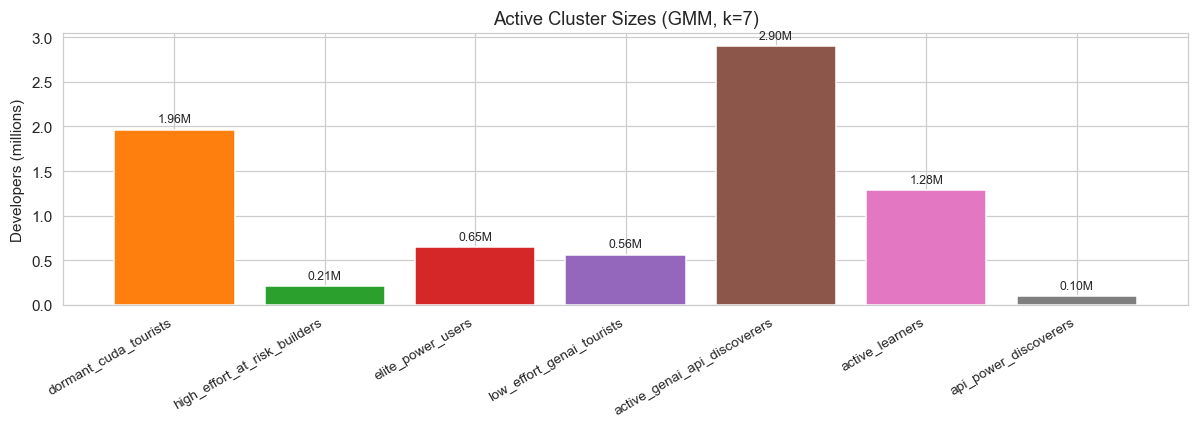

In [12]:
active_size = size_df.loc[size_df.index != -1].copy()
colors = [PALETTE[i] for i in active_size.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(active_size['label'], active_size['n_developers'] / 1e6, color=colors, edgecolor='white')
ax.bar_label(bars, fmt=lambda v: f'{v:.2f}M', padding=3, fontsize=8)
ax.set_ylabel('Developers (millions)')
ax.set_title('Active Cluster Sizes (GMM, k=7)')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Basic feature profiles

Cluster centroids computed in original (pre-scale) feature space and then z-scored across clusters
so features with very different scales can be compared on the same axis.

In [13]:
# centroid_raw already computed in DuckDB (active clusters, original scale)
# Z-score across clusters per feature so all features are comparable
centroid_z = centroid_raw.subtract(centroid_raw.mean()).divide(centroid_raw.std().replace(0, 1))

print('Centroid z-scores (top-variance features):')
top_var = centroid_z.var().sort_values(ascending=False).head(15).index
display(
    centroid_z[top_var].T
    .rename(columns=CLUSTER_LABELS)
    .style.format('{:.2f}')
    .background_gradient(cmap='RdYlGn', axis=1)
)

Centroid z-scores (top-variance features):


gmm_cluster_id,dormant_cuda_tourists,high_effort_at_risk_builders,elite_power_users,low_effort_genai_tourists,active_genai_api_discoverers,active_learners,api_power_discoverers
cuda_share,-1.01,-1.12,1.57,0.04,1.03,-0.43,-0.08
log_clipped_lifetime_activity_count_p99,-1.10,0.33,-0.94,0.63,-0.17,-0.52,1.76
simulation_share,2.05,-1.13,-0.70,0.09,-0.04,-0.10,-0.17
lifetime_avg_effort_rank,1.18,-1.67,-0.99,0.22,0.41,0.80,0.05
log_activity_count_0_30d,-0.52,1.53,-0.57,-0.56,-0.65,-0.62,1.39
lifetime_bug_count,-0.38,-0.38,-0.38,-0.38,-0.38,-0.38,2.27
lifetime_discover_count,-0.63,1.48,-0.62,-0.45,-0.61,-0.62,1.44
lifetime_api_count,-0.58,1.68,-0.58,-0.56,-0.58,-0.58,1.22
learning_community_share,-0.38,-1.25,-1.11,0.72,1.08,1.15,-0.23
mixed_persona_flag,0.52,-1.37,-1.37,1.13,0.73,-0.06,0.41


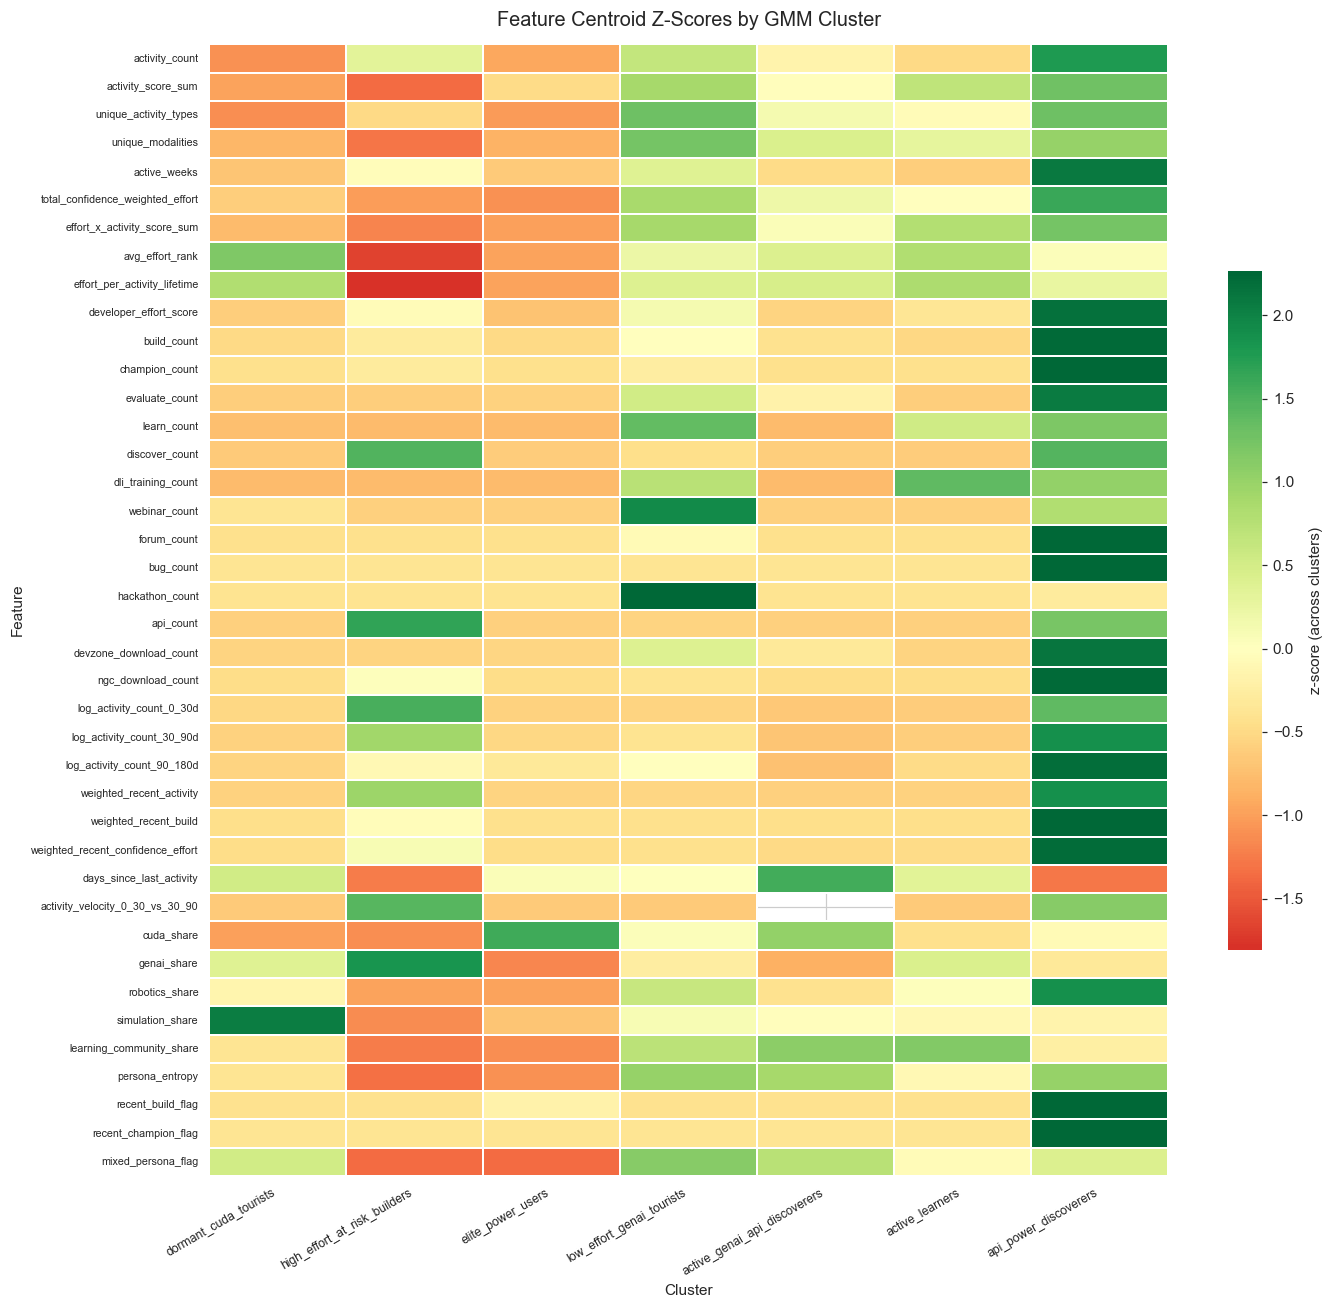

In [14]:
# Full centroid heatmap — all 40 features
heat_data = centroid_z.T.rename(columns=CLUSTER_LABELS)
heat_data.index = [f.replace('lifetime_', '').replace('log_clipped_', '').replace('_p99', '') for f in heat_data.index]

fig, ax = plt.subplots(figsize=(13, 12))
sns.heatmap(
    heat_data,
    cmap='RdYlGn', center=0, linewidths=0.3,
    cbar_kws={'label': 'z-score (across clusters)', 'shrink': 0.6},
    ax=ax,
)
ax.set_title('Feature Centroid Z-Scores by GMM Cluster', fontsize=13, pad=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

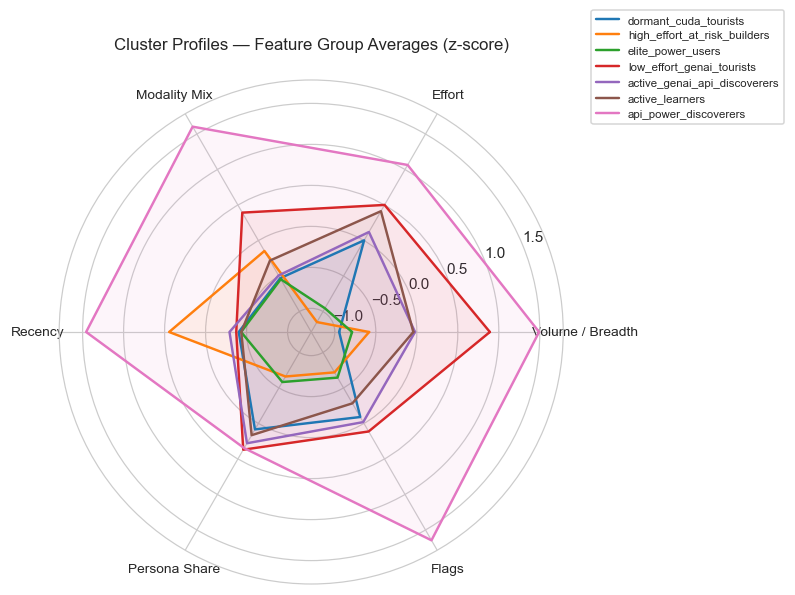

In [15]:
FEATURE_GROUPS = {
    'Volume / Breadth': VOLUME_BREADTH,
    'Effort': EFFORT,
    'Modality Mix': MODALITY_COUNTS,
    'Recency': RECENCY,
    'Persona Share': PERSONA_SHARE,
    'Flags': FLAGS,
}

# Group-mean z-scores
group_z = pd.DataFrame({
    g: centroid_z[[f for f in feats if f in centroid_z.columns]].mean(axis=1)
    for g, feats in FEATURE_GROUPS.items()
})
group_z.index = [CLUSTER_LABELS[i] for i in group_z.index]

categories = list(group_z.columns)
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
palette = sns.color_palette('tab10', len(group_z))
for i, (label, row) in enumerate(group_z.iterrows()):
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, label=label, color=palette[i], linewidth=1.6)
    ax.fill(angles, vals, alpha=0.07, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Cluster Profiles — Feature Group Averages (z-score)', pad=20, fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=7.5)
plt.tight_layout()
plt.show()

In [16]:
print('Median key metrics per active cluster:')
display(
    key_medians.rename(index=CLUSTER_LABELS).T
    .style.format('{:.3f}')
    .background_gradient(cmap='Blues', axis=1)
)

Median key metrics per active cluster:


gmm_cluster_id,dormant_cuda_tourists,high_effort_at_risk_builders,elite_power_users,low_effort_genai_tourists,active_genai_api_discoverers,active_learners,api_power_discoverers
lifetime_activity_count,1.000,5.000,1.000,7.000,3.000,2.000,35.000
lifetime_active_weeks,1.000,2.000,1.000,3.000,1.000,1.000,4.000
developer_effort_score,0.289,1.060,0.152,0.744,0.421,0.448,2.148
days_since_last_activity,564.000,28.000,386.000,370.000,1021.000,496.000,28.000
lifetime_build_count,0.000,0.000,0.000,1.000,1.000,0.000,10.000
lifetime_api_count,0.000,4.000,0.000,0.000,0.000,0.000,0.000
lifetime_learn_count,0.000,0.000,0.000,1.000,0.000,1.000,0.000
lifetime_ngc_download_count,0.000,0.000,0.000,0.000,0.000,0.000,0.000
persona_entropy,-0.000,-0.000,-0.000,0.431,0.429,0.119,0.452
gmm_max_posterior,0.998,1.000,0.999,0.999,0.998,1.000,0.998


## 4. Demographic profiles

Cross-tabulations of held-out profile columns against GMM cluster. The `unactivated` cohort (cluster -1)
is included where it has non-null values.

In [17]:
def crosstab_plot(col, top_n=None, figsize=(12, 4), title=None, rotate=45):
    """Stacked bar from pre-aggregated demo_counts[col] (no raw rows needed)."""
    counts = demo_counts.get(col)
    if counts is None:
        print(f'No aggregated data for {col}')
        return None
    counts = counts.copy()
    counts['gmm_cluster_label'] = counts['gmm_cluster_id'].map(CLUSTER_LABELS)

    if top_n:
        top_vals = counts.groupby(col)['n'].sum().nlargest(top_n).index
        counts = counts[counts[col].isin(top_vals)]

    tab = counts.pivot_table(index='gmm_cluster_label', columns=col,
                              values='n', aggfunc='sum', fill_value=0)
    tab = tab.div(tab.sum(axis=1), axis=0)   # row-normalise

    label_order = [CLUSTER_LABELS[i] for i in CLUSTER_ORDER if CLUSTER_LABELS[i] in tab.index]
    tab = tab.reindex(label_order)

    ax = tab.plot(kind='bar', stacked=True, figsize=figsize, colormap='tab20',
                  edgecolor='white', linewidth=0.3)
    ax.set_title(title or f'Distribution of {col} by Cluster', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Row proportion')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.xticks(rotation=rotate, ha='right', fontsize=8)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, title=col)
    plt.tight_layout()
    plt.show()
    return tab


def quantile_box(col, title=None, figsize=(11, 4), active_only=True):
    """Box-and-whisker using per-cluster quantiles computed entirely in DuckDB."""
    where = 'g.gmm_cluster_id != -1 AND ' if active_only else ''
    q_df = con.execute(f"""
        SELECT g.gmm_cluster_id,
               PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY p.{col}) AS q1,
               PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY p.{col}) AS med,
               PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY p.{col}) AS q3
        FROM dev_gmm_clusters_v1 g
        LEFT JOIN dev_profile_final_v4 p USING (developer_id)
        WHERE {where}p.{col} IS NOT NULL
        GROUP BY g.gmm_cluster_id
    """).fetchdf()
    q_df['label'] = q_df['gmm_cluster_id'].map(CLUSTER_LABELS)
    q_df['iqr'] = q_df['q3'] - q_df['q1']

    label_order = [CLUSTER_LABELS[i] for i in CLUSTER_ORDER if CLUSTER_LABELS[i] in q_df['label'].values]
    q_df = q_df.set_index('label').reindex(label_order)

    stats = [dict(
        med=row['med'], q1=row['q1'], q3=row['q3'],
        whislo=max(row['q1'] - 1.5 * row['iqr'], 0),
        whishi=row['q3'] + 1.5 * row['iqr'],
        fliers=[],
    ) for _, row in q_df.iterrows()]

    colors = [PALETTE[[k for k, v in CLUSTER_LABELS.items() if v == lbl][0]] for lbl in label_order]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.bxp(stats, showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(label_order) + 1))
    ax.set_xticklabels(label_order, rotation=30, ha='right', fontsize=8)
    ax.set_title(title or f'{col} by Cluster', fontsize=11)
    plt.tight_layout()
    plt.show()

### 4.1 Primary persona

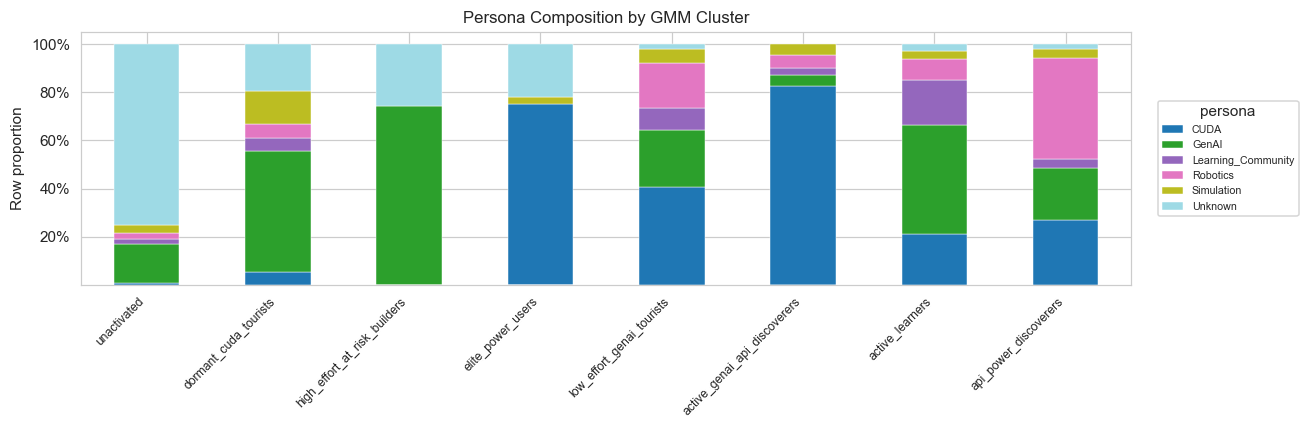


Row-normalised cross-tab (persona):


persona,CUDA,GenAI,Learning_Community,Robotics,Simulation,Unknown
gmm_cluster_label,,,,,,
unactivated,0.006,0.164,0.019,0.025,0.034,0.752
dormant_cuda_tourists,0.055,0.500,0.054,0.059,0.137,0.195
high_effort_at_risk_builders,0.000,0.742,0.000,0.000,0.000,0.258
elite_power_users,0.753,0.000,0.000,0.000,0.025,0.221
low_effort_genai_tourists,0.406,0.237,0.091,0.189,0.056,0.021
active_genai_api_discoverers,0.828,0.046,0.025,0.057,0.044,0.000
active_learners,0.212,0.454,0.186,0.089,0.033,0.026
api_power_discoverers,0.268,0.220,0.038,0.420,0.035,0.020


In [18]:
persona_tab = crosstab_plot('persona', title='Persona Composition by GMM Cluster')
print('\nRow-normalised cross-tab (persona):')
display(persona_tab.round(3))

### 4.2 Lifecycle status

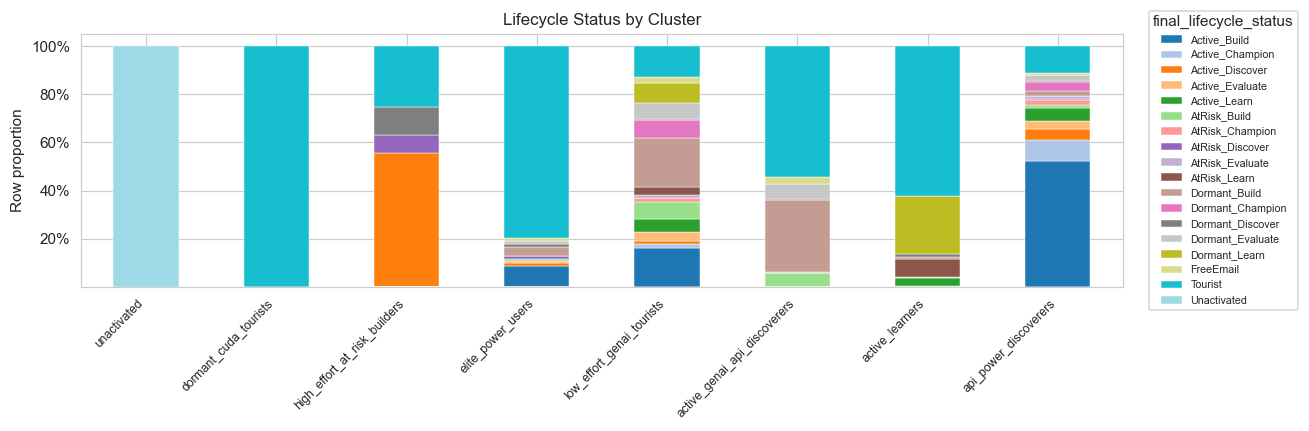


Row-normalised cross-tab (lifecycle):


final_lifecycle_status,Active_Build,Active_Champion,Active_Discover,Active_Evaluate,Active_Learn,AtRisk_Build,AtRisk_Champion,AtRisk_Discover,AtRisk_Evaluate,AtRisk_Learn,Dormant_Build,Dormant_Champion,Dormant_Discover,Dormant_Evaluate,Dormant_Learn,FreeEmail,Tourist,Unactivated
gmm_cluster_label,,,,,,,,,,,,,,,,,,
unactivated,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.0
dormant_cuda_tourists,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.999,0.0
high_effort_at_risk_builders,0.000,0.000,0.558,0.000,0.000,0.000,0.000,0.075,0.000,0.000,0.000,0.000,0.115,0.000,0.000,0.000,0.253,0.0
elite_power_users,0.084,0.000,0.016,0.006,0.000,0.009,0.000,0.011,0.002,0.000,0.039,0.000,0.012,0.010,0.000,0.013,0.798,0.0
low_effort_genai_tourists,0.162,0.014,0.016,0.036,0.052,0.072,0.015,0.002,0.013,0.033,0.206,0.072,0.004,0.067,0.082,0.026,0.127,0.0
active_genai_api_discoverers,0.000,0.000,0.000,0.000,0.000,0.055,0.000,0.002,0.005,0.000,0.297,0.000,0.006,0.064,0.000,0.029,0.542,0.0
active_learners,0.001,0.000,0.001,0.000,0.034,0.003,0.000,0.002,0.000,0.075,0.008,0.000,0.010,0.000,0.245,0.001,0.620,0.0
api_power_discoverers,0.523,0.088,0.045,0.033,0.056,0.013,0.020,0.005,0.010,0.002,0.019,0.036,0.007,0.021,0.003,0.008,0.111,0.0


In [19]:
lc_tab = crosstab_plot('final_lifecycle_status', title='Lifecycle Status by Cluster')
print('\nRow-normalised cross-tab (lifecycle):')
display(lc_tab.round(3))

### 4.3 Dormancy status

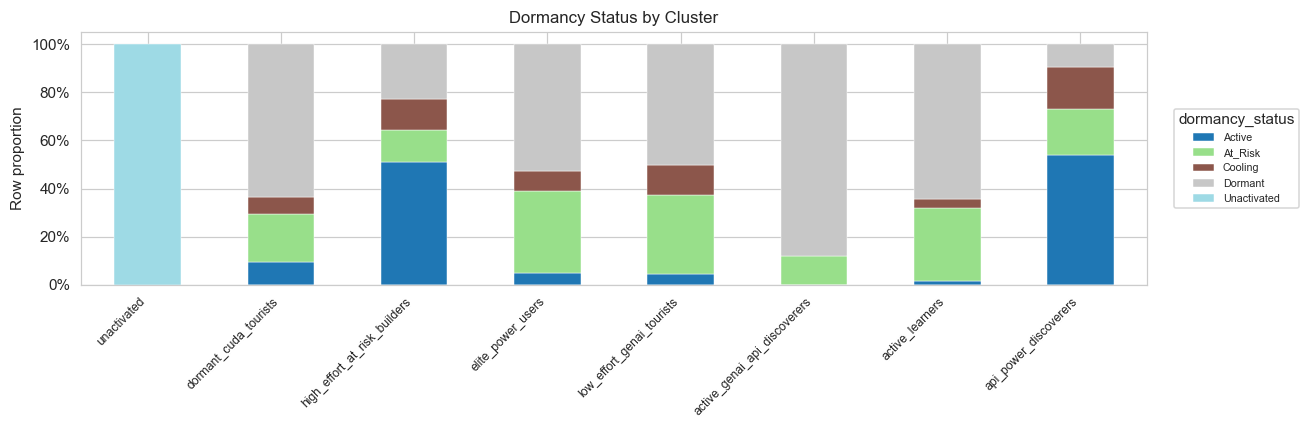

dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
gmm_cluster_label,,,,,
unactivated,0.000,0.000,0.000,0.000,1.0
dormant_cuda_tourists,0.093,0.201,0.071,0.635,0.0
high_effort_at_risk_builders,0.512,0.131,0.130,0.227,0.0
elite_power_users,0.047,0.342,0.085,0.526,0.0
low_effort_genai_tourists,0.046,0.327,0.124,0.504,0.0
active_genai_api_discoverers,0.000,0.120,0.000,0.880,0.0
active_learners,0.016,0.303,0.038,0.644,0.0
api_power_discoverers,0.538,0.191,0.175,0.095,0.0


In [20]:
dorm_tab = crosstab_plot('dormancy_status', title='Dormancy Status by Cluster')
display(dorm_tab.round(3))

### 4.4 Effort level

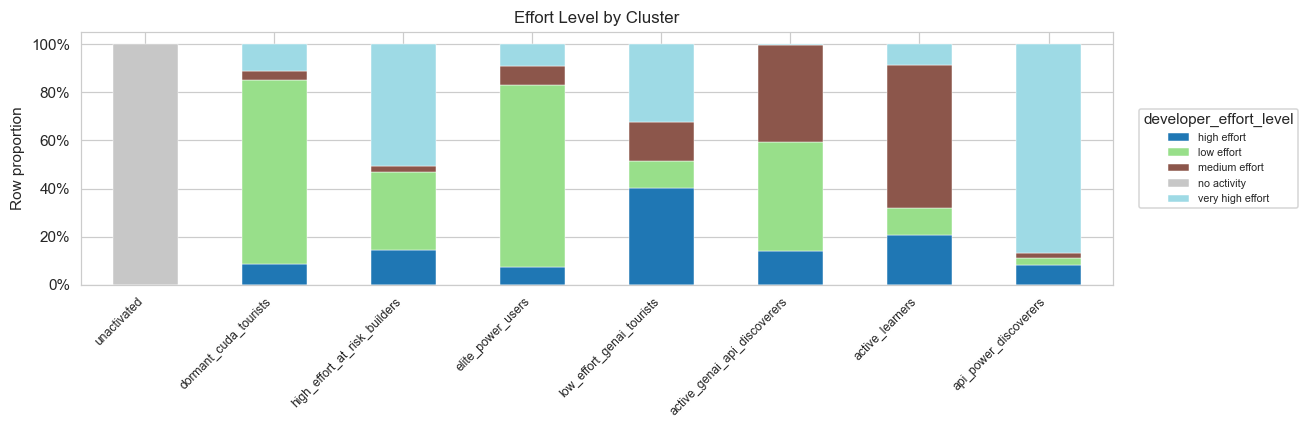

developer_effort_level,high effort,low effort,medium effort,no activity,very high effort
gmm_cluster_label,,,,,
unactivated,0.000,0.000,0.000,1.0,0.000
dormant_cuda_tourists,0.086,0.764,0.040,0.0,0.109
high_effort_at_risk_builders,0.145,0.324,0.025,0.0,0.507
elite_power_users,0.072,0.760,0.078,0.0,0.090
low_effort_genai_tourists,0.403,0.110,0.164,0.0,0.323
active_genai_api_discoverers,0.139,0.456,0.401,0.0,0.004
active_learners,0.207,0.113,0.592,0.0,0.087
api_power_discoverers,0.082,0.029,0.023,0.0,0.866


In [21]:
effort_tab = crosstab_plot('developer_effort_level', title='Effort Level by Cluster')
display(effort_tab.round(3))

### 4.5 Behavior journey stage (30-day)

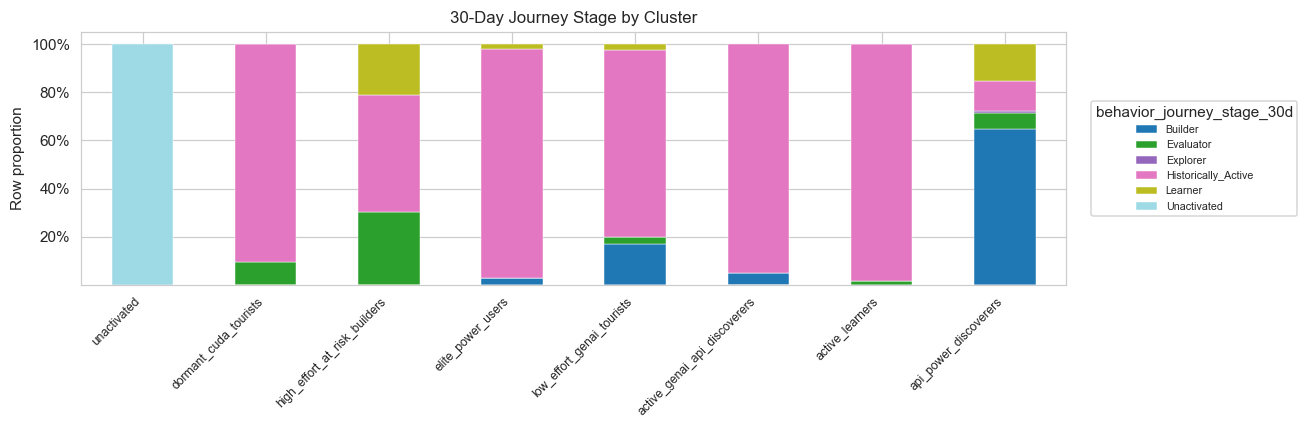

behavior_journey_stage_30d,Builder,Evaluator,Explorer,Historically_Active,Learner,Unactivated
gmm_cluster_label,,,,,,
unactivated,0.000,0.000,0.000,0.000,0.000,1.0
dormant_cuda_tourists,0.000,0.093,0.000,0.907,0.000,0.0
high_effort_at_risk_builders,0.000,0.301,0.000,0.488,0.211,0.0
elite_power_users,0.026,0.002,0.000,0.951,0.020,0.0
low_effort_genai_tourists,0.170,0.029,0.001,0.778,0.022,0.0
active_genai_api_discoverers,0.050,0.000,0.000,0.950,0.000,0.0
active_learners,0.000,0.016,0.000,0.984,0.001,0.0
api_power_discoverers,0.648,0.065,0.008,0.126,0.152,0.0


In [22]:
journey_tab = crosstab_plot('behavior_journey_stage_30d', title='30-Day Journey Stage by Cluster')
display(journey_tab.round(3))

### 4.6 Country (top 15 by total developer count)

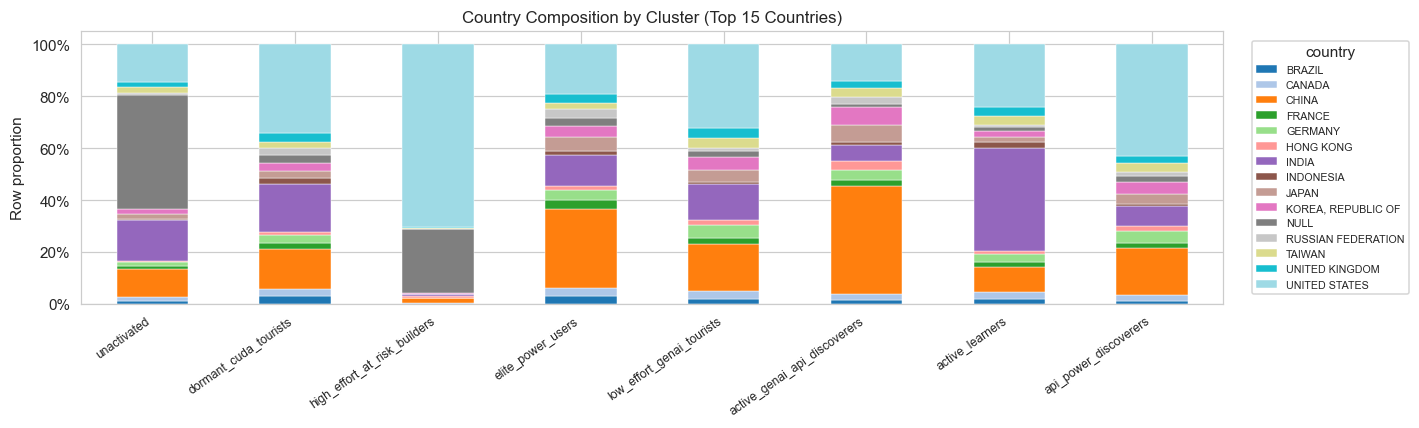


Row-normalised cross-tab (country — top 15):


country,BRAZIL,CANADA,CHINA,FRANCE,GERMANY,HONG KONG,INDIA,INDONESIA,JAPAN,"KOREA, REPUBLIC OF",NULL,RUSSIAN FEDERATION,TAIWAN,UNITED KINGDOM,UNITED STATES
gmm_cluster_label,,,,,,,,,,,,,,,
unactivated,0.013,0.013,0.110,0.010,0.017,0.003,0.155,0.005,0.020,0.020,0.439,0.009,0.022,0.019,0.145
dormant_cuda_tourists,0.031,0.024,0.155,0.023,0.032,0.012,0.184,0.025,0.026,0.031,0.029,0.028,0.023,0.034,0.343
high_effort_at_risk_builders,0.001,0.001,0.019,0.001,0.002,0.008,0.006,0.000,0.002,0.001,0.249,0.000,0.004,0.001,0.705
elite_power_users,0.032,0.027,0.306,0.035,0.039,0.016,0.120,0.015,0.051,0.043,0.034,0.032,0.023,0.035,0.193
low_effort_genai_tourists,0.018,0.031,0.180,0.024,0.050,0.021,0.138,0.009,0.046,0.048,0.023,0.012,0.041,0.038,0.322
active_genai_api_discoverers,0.016,0.021,0.418,0.022,0.039,0.035,0.060,0.011,0.067,0.070,0.010,0.026,0.035,0.027,0.142
active_learners,0.020,0.027,0.094,0.020,0.031,0.010,0.399,0.021,0.018,0.025,0.016,0.005,0.035,0.035,0.243
api_power_discoverers,0.011,0.022,0.181,0.019,0.047,0.020,0.077,0.007,0.040,0.046,0.024,0.012,0.036,0.026,0.432


In [23]:
# Filter to top 15 countries, then plot
_country_all = demo_counts['country']
demo_counts['country'] = _country_all[_country_all['country'].isin(top_countries)]

country_tab = crosstab_plot('country', title='Country Composition by Cluster (Top 15 Countries)',
                            figsize=(13, 4), rotate=35)
demo_counts['country'] = _country_all   # restore full data

print('\nRow-normalised cross-tab (country — top 15):')
display(country_tab.round(3))

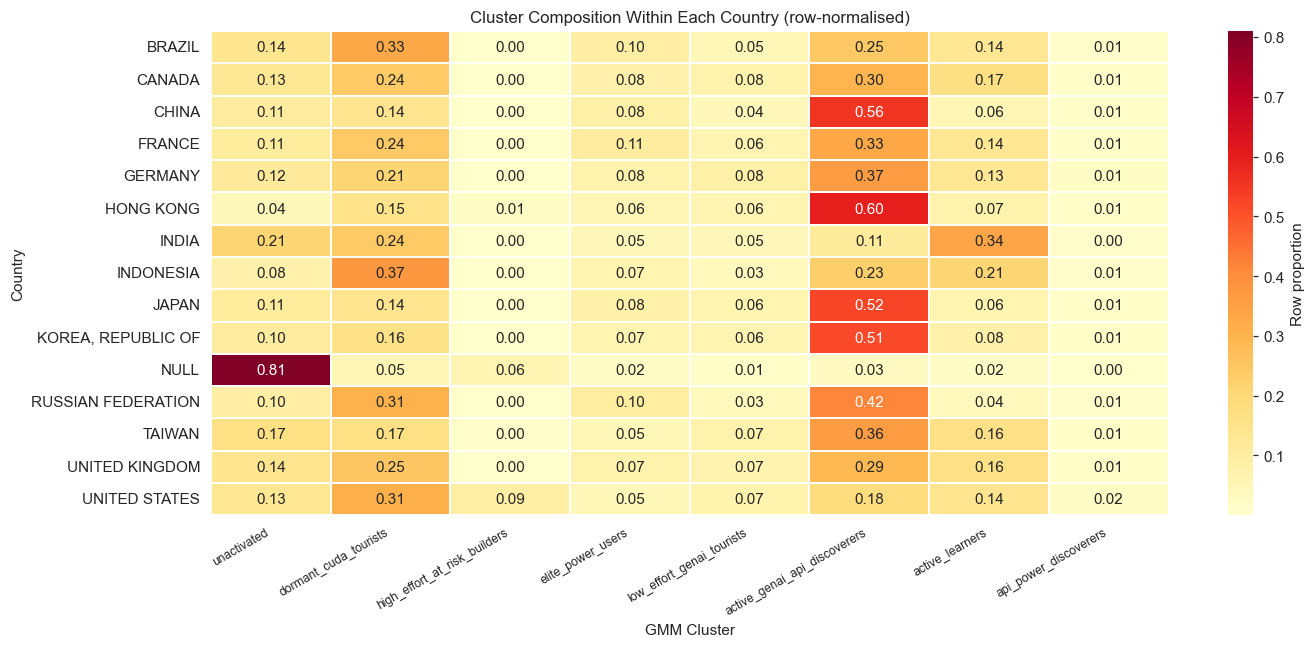

In [24]:
# Pivot: country × cluster, row-normalised
c_top = demo_counts['country'][demo_counts['country']['country'].isin(top_countries)].copy()
c_top['gmm_cluster_label'] = c_top['gmm_cluster_id'].map(CLUSTER_LABELS)

ct_col = c_top.pivot_table(index='country', columns='gmm_cluster_label',
                            values='n', aggfunc='sum', fill_value=0)
ct_col = ct_col.div(ct_col.sum(axis=1), axis=0)
col_order = [CLUSTER_LABELS[i] for i in CLUSTER_ORDER if CLUSTER_LABELS[i] in ct_col.columns]
ct_col = ct_col.reindex(columns=col_order)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(ct_col, cmap='YlOrRd', linewidths=0.3, annot=True, fmt='.2f',
            cbar_kws={'label': 'Row proportion'}, ax=ax)
ax.set_title('Cluster Composition Within Each Country (row-normalised)', fontsize=11)
ax.set_xlabel('GMM Cluster')
ax.set_ylabel('Country')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### 4.7 Account type

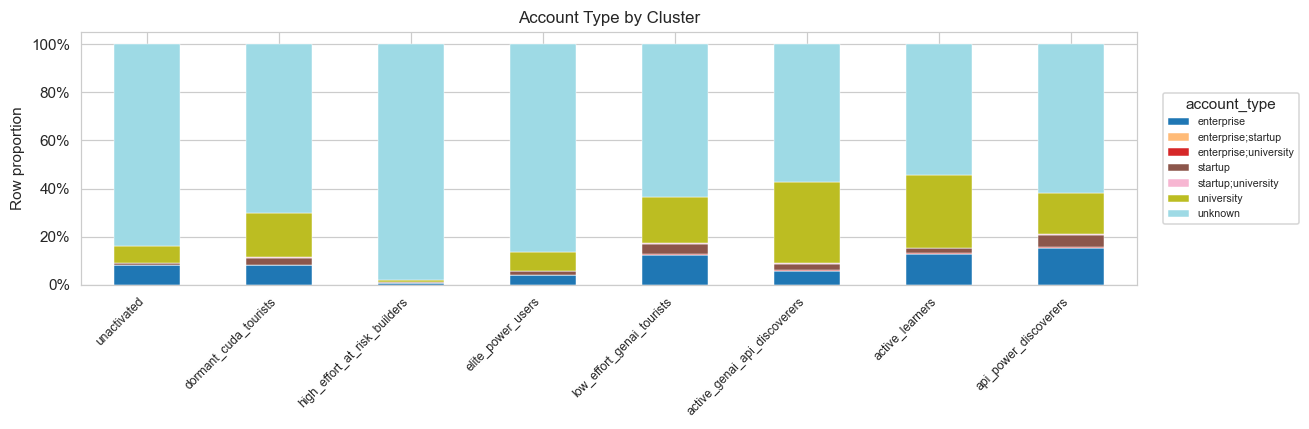

account_type,enterprise,enterprise;startup,enterprise;university,startup,startup;university,university,unknown
gmm_cluster_label,,,,,,,
unactivated,0.080,0.001,0.001,0.009,0.001,0.071,0.837
dormant_cuda_tourists,0.081,0.001,0.001,0.030,0.001,0.187,0.700
high_effort_at_risk_builders,0.008,0.000,0.000,0.004,0.000,0.009,0.979
elite_power_users,0.040,0.001,0.001,0.014,0.000,0.081,0.863
low_effort_genai_tourists,0.123,0.002,0.002,0.044,0.002,0.191,0.635
active_genai_api_discoverers,0.056,0.001,0.003,0.027,0.002,0.338,0.572
active_learners,0.126,0.001,0.003,0.021,0.002,0.302,0.545
api_power_discoverers,0.153,0.002,0.001,0.053,0.002,0.171,0.619


In [25]:
acct_tab = crosstab_plot('account_type', title='Account Type by Cluster')
display(acct_tab.round(3))

### 4.8 Effort rank distribution (numeric)

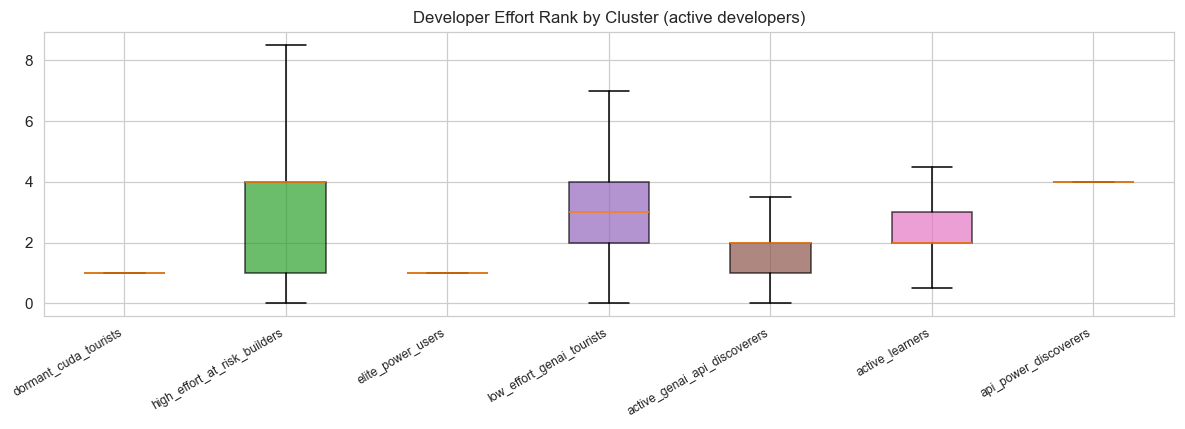

In [26]:
quantile_box('developer_effort_rank',
             title='Developer Effort Rank by Cluster (active developers)')

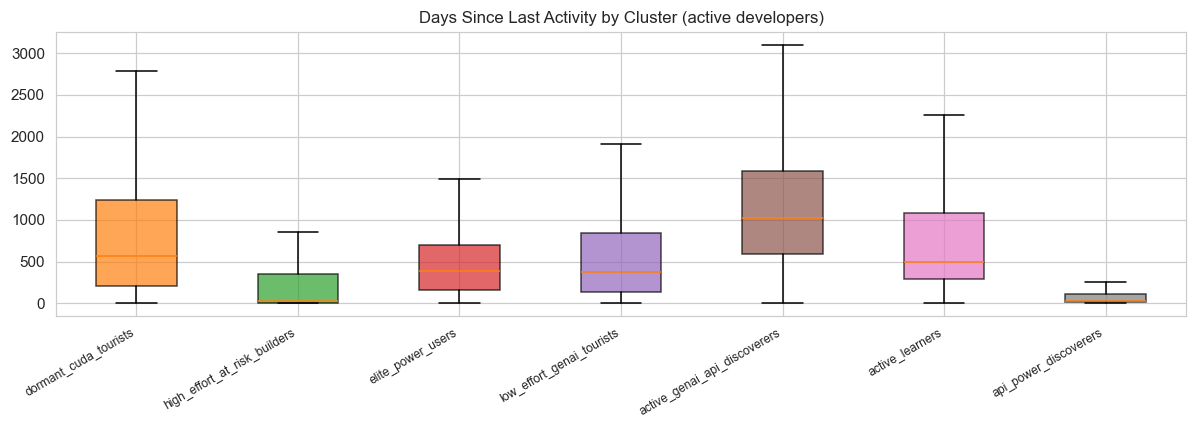

In [27]:
quantile_box('days_since_last_activity',
             title='Days Since Last Activity by Cluster (active developers)')

### 4.9 Modality composition per cluster

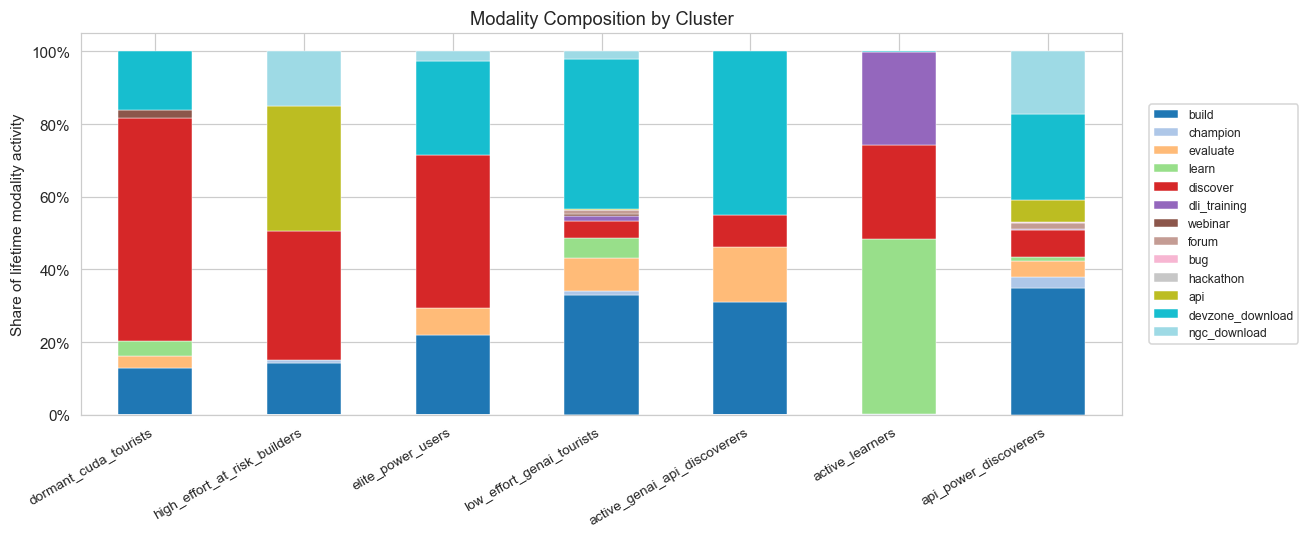

In [28]:
mod_means = centroid_raw[MODALITY_COUNTS].copy()
mod_share = mod_means.div(mod_means.sum(axis=1), axis=0)
mod_share.index = [CLUSTER_LABELS[i] for i in mod_share.index]
mod_share.columns = [c.replace('lifetime_', '').replace('_count', '') for c in mod_share.columns]

ax = mod_share.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='tab20',
                    edgecolor='white', linewidth=0.3)
ax.set_ylabel('Share of lifetime modality activity')
ax.set_title('Modality Composition by Cluster')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## 5. Summary reference table

Combines cluster size, dominant persona, lifecycle, dormancy, effort level, and top country
into a single reference frame.

In [29]:
def get_mode(col, cluster_id):
    counts = demo_counts.get(col)
    if counts is None:
        return None
    subset = counts[counts['gmm_cluster_id'] == cluster_id]
    return subset.loc[subset['n'].idxmax(), col] if not subset.empty else None

rows = []
for cid in CLUSTER_ORDER:
    sz = size_df.loc[cid] if cid in size_df.index else pd.Series(dtype=float)
    km = key_medians.loc[cid] if cid in key_medians.index else pd.Series(dtype=float)
    rows.append({
        'cluster_id':              cid,
        'label':                   CLUSTER_LABELS[cid],
        'n_developers':            int(sz.get('n_developers', 0)),
        'pct_of_all':              round(float(sz.get('pct_of_all', 0)), 1),
        'top_persona':             get_mode('persona', cid),
        'top_lifecycle':           get_mode('final_lifecycle_status', cid),
        'top_dormancy':            get_mode('dormancy_status', cid),
        'top_effort':              get_mode('developer_effort_level', cid),
        'top_country':             get_mode('country', cid),
        'top_account_type':        get_mode('account_type', cid),
        'median_days_since':       round(float(km['days_since_last_activity']), 0) if 'days_since_last_activity' in km else None,
        'median_effort_score':     round(float(km['developer_effort_score']), 3) if 'developer_effort_score' in km else None,
        'avg_max_posterior':       round(float(sz.get('mean_max_posterior', 0)), 4),
    })

summary_df = pd.DataFrame(rows).set_index('cluster_id')
print('=== GMM Cluster Summary Reference Table ===')
display(
    summary_df.style
    .format({'n_developers': '{:,.0f}', 'pct_of_all': '{:.1f}%', 'avg_max_posterior': '{:.4f}'})
)

=== GMM Cluster Summary Reference Table ===


,label,n_developers,pct_of_all,top_persona,top_lifecycle,top_dormancy,top_effort,top_country,top_account_type,median_days_since,median_effort_score,avg_max_posterior
cluster_id,,,,,,,,,,,,
-1,unactivated,"1,718,912",18.3%,Unknown,Unactivated,Unactivated,no activity,NULL,unknown,nan,nan,1.0000
0,dormant_cuda_tourists,"1,960,290",20.9%,GenAI,Tourist,Dormant,low effort,UNITED STATES,unknown,564.000000,0.289000,0.9980
1,high_effort_at_risk_builders,"209,808",2.2%,GenAI,Active_Discover,Active,very high effort,UNITED STATES,unknown,28.000000,1.060000,1.0000
2,elite_power_users,"646,592",6.9%,CUDA,Tourist,Dormant,low effort,CHINA,unknown,386.000000,0.152000,0.9992
3,low_effort_genai_tourists,"563,929",6.0%,CUDA,Dormant_Build,Dormant,high effort,UNITED STATES,unknown,370.000000,0.744000,0.9987
4,active_genai_api_discoverers,"2,901,046",30.9%,CUDA,Tourist,Dormant,low effort,CHINA,unknown,1021.000000,0.421000,0.9983
5,active_learners,"1,282,345",13.7%,GenAI,Tourist,Dormant,medium effort,INDIA,unknown,496.000000,0.448000,0.9996
6,api_power_discoverers,"96,268",1.0%,Robotics,Active_Build,Active,very high effort,UNITED STATES,unknown,28.000000,2.148000,0.9984


In [30]:
DESCRIPTIONS = {
    -1: (
        "Structural holdout — zero lifetime activity. Excluded from GMM fit and reattached "
        "as pseudo-cluster -1. Largest single cohort by raw count."
    ),
    0: (
        "CUDA-persona majority, predominantly dormant/tourist lifecycle, historically active "
        "journey stage. Low-to-medium effort. These developers registered, did some early "
        "activity (often builds or DevZone downloads), and have gone quiet."
    ),
    1: (
        "Multi-modal, high-effort developers (high build + DevZone z-scores) sliding toward "
        "churn. Mixed CUDA/GenAI/Robotics persona. Elevated at-risk and dormant lifecycle "
        "shares. Re-engagement priority segment."
    ),
    2: (
        "Top-tier power users — extreme NGC download, build, champion, API, and forum z-scores. "
        "Highest active-build lifecycle share. Most valuable and sticky segment; highest "
        "absolute engagement across every modality."
    ),
    3: (
        "GenAI wave sign-ups: ~99.7% Tourist lifecycle, near-zero modality engagement, "
        "predominantly dormant. Low effort across all metrics. Likely registered during a "
        "GenAI launch event but never converted to active usage."
    ),
    4: (
        "Most recently active cluster (lowest days_since_last_activity). High API and discover "
        "z-scores, elevated activity velocity. GenAI-focused with active-discover lifecycle. "
        "Current-moment explorers engaging the API and discovery layer."
    ),
    5: (
        "Learner-focused segment: high learn_count and DLI training z-scores relative to other "
        "clusters. Moderate activity, primarily engaged through structured learning pathways "
        "(DLI, webinars). Potential pipeline for deeper ecosystem engagement."
    ),
    6: (
        "API-and-discovery power users: extreme API count and discover z-scores, high velocity. "
        "Recently active, likely programmatic/production API consumers or aggressive explorers. "
        "Distinct from cluster 4 in the scale of API and discover engagement."
    ),
}

print('=== Cluster Narrative Descriptions ===')
for cid in CLUSTER_ORDER:
    label = CLUSTER_LABELS[cid]
    n = int(summary_df.loc[cid, 'n_developers'])
    pct = float(summary_df.loc[cid, 'pct_of_all'])
    print(f'\n[{cid}] {label}  |  n={n:,}  ({pct:.1f}%)')
    print(f'    {DESCRIPTIONS[cid]}')

=== Cluster Narrative Descriptions ===

[-1] unactivated  |  n=1,718,912  (18.3%)
    Structural holdout — zero lifetime activity. Excluded from GMM fit and reattached as pseudo-cluster -1. Largest single cohort by raw count.

[0] dormant_cuda_tourists  |  n=1,960,290  (20.9%)
    CUDA-persona majority, predominantly dormant/tourist lifecycle, historically active journey stage. Low-to-medium effort. These developers registered, did some early activity (often builds or DevZone downloads), and have gone quiet.

[1] high_effort_at_risk_builders  |  n=209,808  (2.2%)
    Multi-modal, high-effort developers (high build + DevZone z-scores) sliding toward churn. Mixed CUDA/GenAI/Robotics persona. Elevated at-risk and dormant lifecycle shares. Re-engagement priority segment.

[2] elite_power_users  |  n=646,592  (6.9%)
    Top-tier power users — extreme NGC download, build, champion, API, and forum z-scores. Highest active-build lifecycle share. Most valuable and sticky segment; highest absolu

In [31]:
con.close()
print('DuckDB connection closed.')

DuckDB connection closed.
